<a href="https://colab.research.google.com/github/Guru-CS/Global-Aviation-Incidents-Research/blob/main/GlobalAviationIncidentsResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5035 entries, 0 to 5034
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Year                   5035 non-null   int64 
 1   Quarter                5035 non-null   object
 2   Month                  5035 non-null   object
 3   Day                    5035 non-null   int64 
 4   Country/Region         4805 non-null   object
 5   Aircraft Manufacturer  5035 non-null   object
 6   Aircraft               5035 non-null   object
 7   Location               5035 non-null   object
 8   Operator               4801 non-null   object
 9   Ground                 5035 non-null   int64 
 10  Fatalities (air)       5035 non-null   int64 
 11  Aboard                 5035 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 472.2+ KB


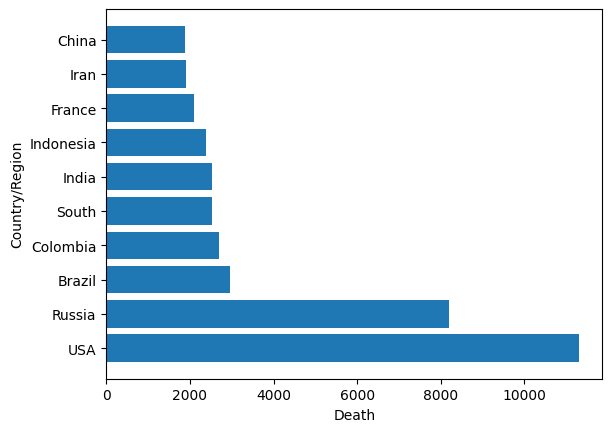

21
25
46


/tmp/ipykernel_1880/26880658.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


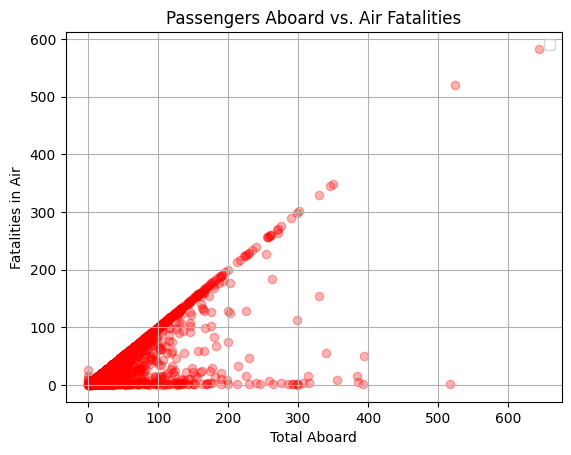

KeyError: ('Manufacturer_Grouped', 'Aircraft_Grouped', 'Aircraft_Operator', 'Country/Region', 'Aboard')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
data= pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Global%20Aviation%20Incidents/aircrashesFullDataUpdated_2024.csv")
data.info()
data.head()
data['Aircraft Manufacturer'] = data['Aircraft Manufacturer'].astype(str).str.strip()
data['Aircraft'] = data['Aircraft'].astype(str).str.strip()
data['Manufacturer_Grouped'] = data['Aircraft Manufacturer'].where(
    data.groupby('Aircraft Manufacturer')['Aircraft Manufacturer'].transform('count') > 15,
    'Other'
)
data['Aircraft_Grouped'] = data['Aircraft'].where(
    data.groupby('Aircraft')['Aircraft'].transform('count') > 15,
    'Other'
)
data['Aircraft_Operator'] = data['Operator'].where(
    data.groupby('Operator')['Operator'].transform('count') > 15,
    'Other'
)
# Did not type all the location mapping used AI and there are still countries i could add
location_mapping = {
'alabama': 'USA',
    'alaska': 'USA',
    'arizona': 'USA',
    'arkansas': 'USA',
    'california': 'USA',
    'colorado': 'USA',
    'connecticut': 'USA',
    'delaware': 'USA',
    'florida': 'USA',
    'georgia': 'USA',
    'hawaii': 'USA',
    'idaho': 'USA',
    'illinois': 'USA',
    'indiana': 'USA',
    'iowa': 'USA',
    'kansas': 'USA',
    'kentucky': 'USA',
    'louisiana': 'USA',
    'maine': 'USA',
    'maryland': 'USA',
    'massachusetts': 'USA',
    'michigan': 'USA',
    'minnesota': 'USA',
    'mississippi': 'USA',
    'missouri': 'USA',
    'montana': 'USA',
    'nebraska': 'USA',
    'nevada': 'USA',
    'new hampshire': 'USA',
    'new jersey': 'USA',
    'new mexico': 'USA',
    'new york': 'USA',
    'north carolina': 'USA',
    'north dakota': 'USA',
    'ohio': 'USA',
    'oklahoma': 'USA',
    'oregon': 'USA',
    'pennsylvania': 'USA',
    'rhode island': 'USA',
    'south carolina': 'USA',
    'south dakota': 'USA',
    'tennessee': 'USA',
    'texas': 'USA',
    'utah': 'USA',
    'vermont': 'USA',
    'virginia': 'USA',
    'washington': 'USA',
    'west virginia': 'USA',
    'wisconsin': 'USA',
    'wyoming': 'USA'
}
for keyword, clean_name in location_mapping.items():
    mask = data['Country/Region'].str.contains(keyword, case=False, na=False)
    data.loc[mask, 'Country/Region'] = clean_name
filtered_df=data.drop_duplicates()
filtered_df = filtered_df[filtered_df['Country/Region'].str.strip().str.lower() != 'new']
filtered_df = filtered_df[(filtered_df['Fatalities (air)']>0)|(filtered_df['Ground']>0)]
filtered_df["Total Fatalities"]=filtered_df['Fatalities (air)'] + filtered_df['Ground']
plt.xlabel("Death")
plt.ylabel("Country/Region")
top_locations = (filtered_df.groupby("Country/Region")["Total Fatalities"].sum().sort_values(ascending=False).head(10))
plt.barh(top_locations.index, top_locations.values)
plt.show()
print(filtered_df['Aircraft_Grouped'].nunique())
print(filtered_df['Aircraft_Operator'].nunique())
print(filtered_df['Manufacturer_Grouped'].nunique())
filtered_df.head(50)
plt.scatter(filtered_df['Aboard'], filtered_df['Fatalities (air)'], alpha=0.3, color='red')
plt.title('Passengers Aboard vs. Air Fatalities')
plt.xlabel('Total Aboard')
plt.ylabel('Fatalities in Air')
plt.legend()
plt.grid(True)
plt.show()
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import *
from sklearn.datasets import *
filtered_df['Completely_Fatal'] = (
    filtered_df['Fatalities (air)'] >= filtered_df['Aboard']
).astype(int)


x = filtered_df['Manufacturer_Grouped', 'Aircraft_Grouped', 'Aircraft_Operator','Country/Region','Aboard'].copy()
y = filtered_df['Completely_Fatal'].copy()
#learn target encoding
x = x.dropna()
y = y.loc[x.index]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(x_train, y_train)



